## Section 1: Setting up the Data

In [107]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

df_gender = pd.read_csv("gender_submission.csv")
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Section 2: Data Analysis/Prediction
Who had higher survival rates? Men or women?

In [108]:
# Encode Sex to Numbers
df_train["Sex"] = df_train["Sex"].map({"female":0, "male":1})

In [109]:
# Getting rid of any null values in the age column
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
df_train.dropna(inplace=True)
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",0,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",0,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",0,47.0,1,1,11751,52.5542,D35,S
872,873,0,1,"Carlsson, Mr. Frans Olof",1,33.0,0,0,695,5.0000,B51 B53 B55,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",0,56.0,0,1,11767,83.1583,C50,C
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S


Sex
0    0.936842
1    0.420561
Name: Survived, dtype: float64


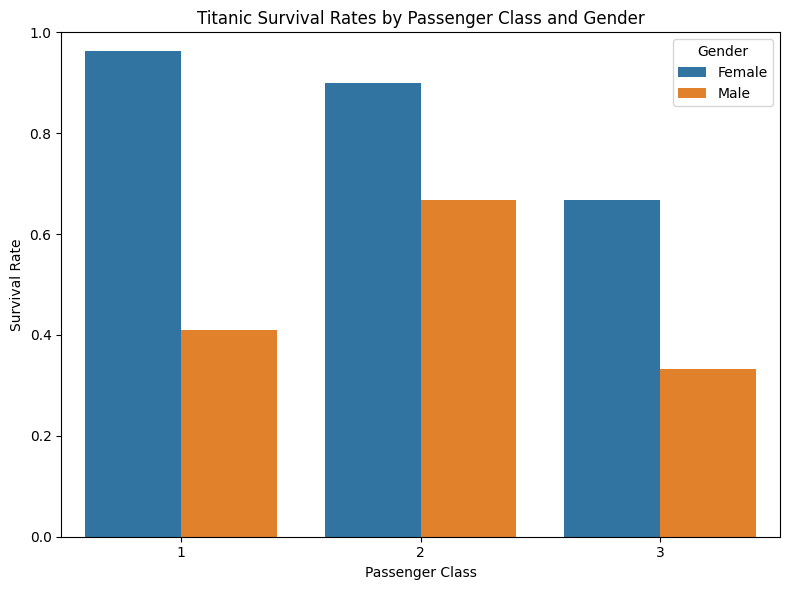

In [110]:
print(df_train.groupby('Sex')['Survived'].mean())
# df_train["Sex"].plot.bar(title="", xlabel="", ylabel="")

# Survival rate by class and gender
survival_rates = df_train.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()

# If "Sex" is still encoded, map it back for clarity
survival_rates['Sex'] = survival_rates['Sex'].map({0: 'Female', 1: 'Male'})

# Create the bar plot
plt.figure(figsize=(8,6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=survival_rates)
plt.title('Titanic Survival Rates by Passenger Class and Gender')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.ylim(0, 1)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

The barplot shows the average survival rates by passenger class and gender. This visual was generated using `pandas` for grouping and `seaborn` for plotting.

In [111]:
X = df_train[["Pclass", "Sex", "Age"]]
y = df_train["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print("Confusion Matrix:")
print(cm)
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coeffs)


Accuracy: 0.83
Precision: 0.91
Recall: 0.88
F1 Score: 0.89
Confusion Matrix:
[[ 5  3]
 [ 4 29]]
  Feature  Coefficient
0  Pclass    -0.495252
1     Sex    -2.300176
2     Age    -0.027237


## Section 3: Data Interpretation
### 🚢Titanic Survival Analysis by Class and Gender
Notes:  
I encoded females to be 0 and males to be 1  
Positive coefficient increases the probability of survival  
Negative coefficient decreases the probability of survival  
The larger the coefficient's absolute value, the stronger the influence of that feature 

<h2 style="color: red;"> Key Observations:</h2>

Based on the results:  
A value of 0.83 for accuracy means 83% of predictions matched actual survival outcomes.  
A value of 0.91 for precision means when the model predicted survival, it was correct 91% of the time.  
A value of 0.88 for recall means the model correctly identified 88% of actual survivors.  
A value of 0.89 for F1 score means it balances precision and recall. 

These numbers show that the model is doing well at predicting who survived


The confusion matrix shows:
* Correctly identified 29 survivors
* Missed 4 real survivors (False negatives)
* Incorrectly predicted survival for 3 who did not survive (False positives)

Females showed higher survival rates than males (with females having an overall survival rate of 94% and males with 42%)  
This can align with the "women and children first" protocol

